### Ex 10

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

faces = fetch_olivetti_faces(random_state=52)
X = faces.data
y = faces.target

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=80, stratify=y, random_state=52)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=80, stratify=y_train, random_state=52)

In [4]:
X_train.shape

(240, 4096)

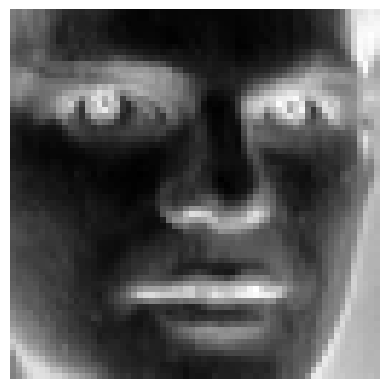

In [5]:
def plot_face(face_data):
    face = (face_data.reshape(64, 64))*255
    plt.imshow(face, cmap='binary')
    plt.axis('off')

plot_face(X_train[0])

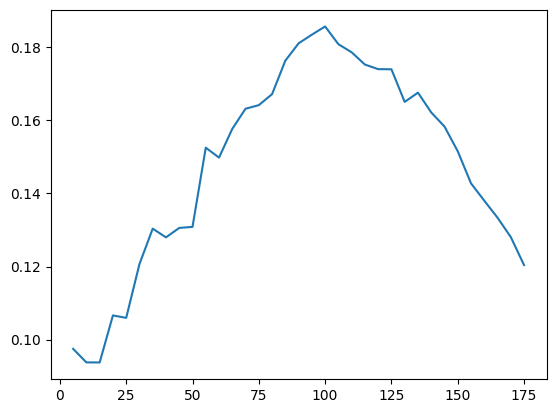

[[100.           0.18569295]]


In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

table = []

for k in range(5, 180, 5):
    km = KMeans(n_clusters=k, random_state=52).fit(X_train)
    table.append([k, silhouette_score(X_train, km.labels_)])
    
    
table = np.array(table).reshape(-1, 2)
plt.plot(table[:,0], table[:,1])

plt.show()
print(table[table[:, 1] == table[:, 1].max()])

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans

In [8]:
class Kmeans_feature(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
        # self._n_clusters = n_clusters
        # self._random_state = random_state
        
    def fit(self, X, y=None):
        self._k_means = KMeans(n_clusters=100, random_state=52)
        self._k_means.fit(X)
        return self
        
    def transform(self, X):
        labels = MinMaxScaler((0, 1)).fit_transform(self._k_means.predict(X).reshape(-1, 1))
        rows, columns = X.shape
        X_final = np.zeros((rows, columns+1))
        X_final[:, :-1] = X
        X_final[:, -1]=labels.reshape(rows)
        return X_final

In [9]:
model = Pipeline([("preprocessing", Kmeans_feature()), ("rf", RandomForestClassifier(random_state=52))])

In [10]:
X_transformed = Kmeans_feature().fit_transform(X_train)
print(X_transformed.shape)
print(X_train.shape)

(240, 4097)
(240, 4096)


In [11]:
cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")

array([0.875     , 0.875     , 0.875     , 0.91666667, 0.89583333])

In [12]:
model.fit(X_train, y_train)
model.score(X_valid, y_valid)

0.9375

In [13]:
model.score(X_test, y_test)

0.9375

In [ ]:
X_extended = np.zeros((320, 4096))
X_extended[:240, :] = X_train
X_extended[240:, :] = X_valid

y_extended = np.zeros

(240,)

#### Ex 11

In [67]:
class Kmeans_reduction(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
        # self._n_clusters = n_clusters
        # self._random_state = random_state
        
    def fit(self, X, y=None):
        self._k_means = KMeans(n_clusters=100, random_state=52)
        self._k_means.fit(X)
        return self
        
    def transform(self, X):
        labels = MinMaxScaler((0, 1)).fit_transform(self._k_means.transform(X))
        return labels
    
    
model_2 = Pipeline([("preprocessing", Kmeans_reduction()), ("rf", RandomForestClassifier(random_state=52))])

In [68]:
X_transformed = Kmeans_reduction().fit_transform(X_train)
X_transformed.shape

(240, 100)

In [74]:
cross_val_score(model_2, X_train, y_train, cv=5, scoring="accuracy")

array([0.25      , 0.1875    , 0.22916667, 0.20833333, 0.25      ])

In [ ]:
class Kmeans_reduction_features(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
        # self._n_clusters =model.score(X_valid, y_valid) n_clusters
        # self._random_state = random_state
        
    def fit(self, X, y=None):
        #self.features_table = Kmeans_feature().fit_transform(X)
        self._k_means = KMeans(n_clusters=100, random_state=52)
        self._k_means.fit(X)
        #self.labels = MinMaxScaler((0, 1)).fit_transform(self._k_means.transform(X))
        return self
        
    def transform(self, X):
        
        features_table = Kmeans_feature().fit_transform(X)
        labels = MinMaxScaler((0, 1)).fit_transform(self._k_means.transform(X))
         
        rows, columns = features_table.shape
        rows_l, columns_l = labels.shape
        if rows_l != rows:
            print("ROWS ERROR!!!\n")
        X_finale = np.zeros((rows, columns+100))
        X_finale[:, :-100] = features_table
        X_finale[:, -100:] = labels
        return X_finale
    
    
X_transformed = Kmeans_reduction_features().fit_transform(X_train)
X_transformed.shape

(240, 4197)

In [126]:
X_transformed[1][-200:-1].round(3)

array([0.368, 0.347, 0.302, 0.298, 0.326, 0.335, 0.335, 0.372, 0.388,
       0.388, 0.355, 0.343, 0.368, 0.388, 0.36 , 0.355, 0.405, 0.413,
       0.376, 0.343, 0.326, 0.231, 0.178, 0.14 , 0.165, 0.198, 0.256,
       0.244, 0.231, 0.24 , 0.182, 0.14 , 0.145, 0.14 , 0.157, 0.43 ,
       0.57 , 0.686, 0.492, 0.508, 0.893, 0.876, 0.826, 0.335, 0.31 ,
       0.339, 0.335, 0.289, 0.24 , 0.219, 0.24 , 0.285, 0.376, 0.438,
       0.467, 0.45 , 0.434, 0.438, 0.426, 0.413, 0.417, 0.413, 0.442,
       0.446, 0.459, 0.459, 0.426, 0.446, 0.438, 0.442, 0.421, 0.45 ,
       0.459, 0.446, 0.397, 0.388, 0.409, 0.397, 0.401, 0.355, 0.388,
       0.376, 0.364, 0.285, 0.244, 0.157, 0.153, 0.165, 0.165, 0.231,
       0.26 , 0.244, 0.211, 0.26 , 0.207, 0.14 , 0.145, 0.136, 0.145,
       0.768, 0.597, 0.83 , 0.855, 0.161, 0.745, 0.817, 0.555, 0.857,
       0.831, 0.412, 0.809, 0.613, 0.632, 0.798, 0.715, 0.808, 0.679,
       0.307, 0.486, 0.737, 0.88 , 0.587, 0.772, 0.796, 0.832, 0.86 ,
       0.226, 0.648,

In [127]:
model_3 = Pipeline([("preprocessing", Kmeans_reduction_features()), ("rf", RandomForestClassifier(random_state=52))])
model_3.fit(X_train, y_train)

def accuracy(model, X_valid, y_valid):
    y_pred = model.predict(X_valid)
    y_answ = [(y_pred==y_valid)]
    return np.mean(y_answ)




In [130]:
cross_val_score(model_3, X_train, y_train, cv=2, scoring="accuracy")

array([0.66666667, 0.65      ])

In [115]:
y_valid.shape

(80,)

### Ex 12

In [13]:
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

pca = PCA(n_components=0.99)
X_reduced = pca.fit_transform(X_train)


bic_aic = []
for k in range(1, 10, 1):
    gmt = GaussianMixture(n_components=k, n_init=10, max_iter=500, random_state=52)
    gmt.fit(X_reduced)
    bic_aic.append([k, gmt.bic(X_reduced), gmt.aic(X_reduced)])
    


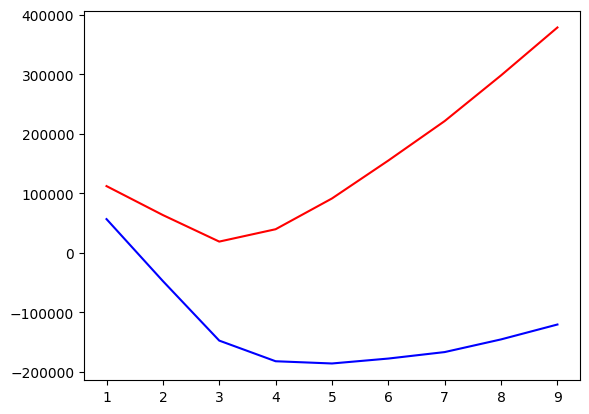

In [14]:
bic_aic = np.array(bic_aic)
plt.plot(bic_aic[:, 0], bic_aic[:, 1], "r")
plt.plot(bic_aic[:, 0], bic_aic[:, 2], "b")

In [ ]:
print(bic_aic[bic_aic[:, 1]==bic_aic[:, 1].min()])
bic_aic[bic_aic[:, 2]==bic_aic[:, 2].min()]
#I will choose 3 for BIC

[[ 3.00000000e+00  1.89634786e+04 -1.47383217e+05]]


array([[ 5.00000000e+00,  9.14265511e+04, -1.85820262e+05]])

In [27]:
X_reduced[1].round(3)

array([-9.689e+00, -5.160e-01, -6.340e-01,  1.600e-02, -1.816e+00,
       -1.306e+00, -6.000e-03,  5.540e-01, -1.664e+00, -2.740e-01,
       -4.190e-01,  4.830e-01, -2.960e-01,  1.240e+00, -5.820e-01,
        7.350e-01, -5.110e-01,  1.713e+00,  5.430e-01, -2.082e+00,
        7.270e-01,  1.780e-01, -5.020e-01,  4.520e-01, -4.650e-01,
        1.040e-01,  6.000e-02,  6.430e-01,  7.620e-01, -7.040e-01,
        3.170e-01, -4.330e-01,  7.400e-01, -5.310e-01, -4.780e-01,
       -1.570e-01, -6.830e-01, -3.920e-01,  2.580e-01,  4.310e-01,
        2.460e-01,  1.020e-01,  4.470e-01,  2.910e-01,  2.100e-02,
        7.700e-02,  9.200e-02, -1.800e-02,  7.200e-02,  1.900e-01,
       -2.910e-01, -4.650e-01,  6.700e-02, -2.900e-02,  6.200e-02,
        1.820e-01, -2.460e-01,  5.190e-01,  6.200e-02, -2.650e-01,
       -2.560e-01, -6.900e-02,  7.000e-02,  3.200e-01,  2.560e-01,
       -1.200e-02,  4.690e-01, -2.670e-01, -3.160e-01, -2.510e-01,
       -2.040e-01, -1.780e-01, -4.490e-01, -3.340e-01,  1.980e

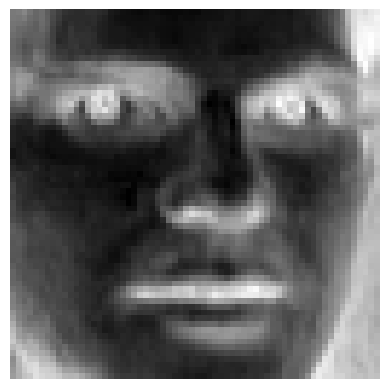

In [29]:
new_face = pca.inverse_transform(X_reduced[0].reshape(1, -1))
plot_face(new_face)

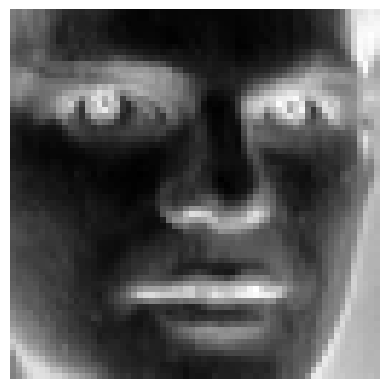

In [ ]:
#almost no difference
plot_face(X_train[0])

In [32]:
gm = GaussianMixture(n_components=3, n_init=10, max_iter=500, random_state=52)
gm.fit(X_reduced)

,"n_components n_components: int, default=1The number of mixture components.",3
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",500
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",10
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",52


In [34]:
densities = gm.score_samples(X_reduced)
threshold = np.percentile(densities, 2)
anomalies = X_reduced[densities<threshold]

anomalies.shape

(4, 177)

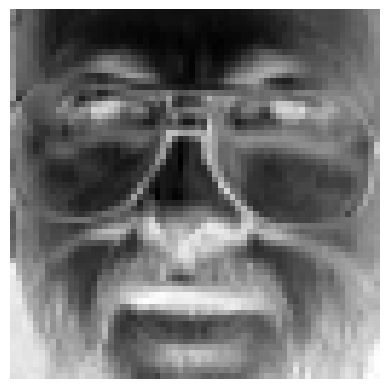

In [ ]:
#4 anomalies totaly
plot_face(pca.inverse_transform(anomalies[1].reshape(1, -1)))

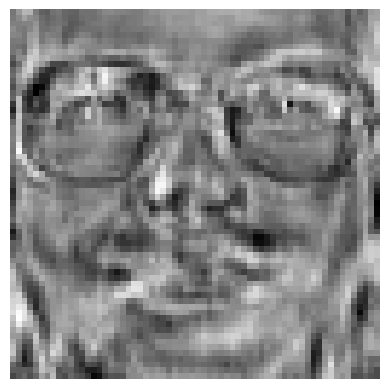

In [62]:
X_changed = X_reduced.copy()
X_changed[3][10:30] = 0
X_changed[3][70:85] = 11

plot_face(pca.inverse_transform(X_changed[3].reshape(1, -1)))


In [63]:
densities = gm.score_samples(X_changed)
threshold = np.percentile(densities, 2)
anomalies_2 = X_changed[densities<threshold]

anomalies_2.shape

(5, 177)

### Ex 13

In [69]:
X_reconstruced = pca.inverse_transform(X_reduced)

def mean_square_dist(X_1, X_2):
    X = X_1 - X_2
    result = 0
    for x in X:
        result += np.pow(x, 2)
        
    result = result/len(X)
    return result

error = 0
for i in range(240):
     error += mean_square_dist(X_reconstruced[i], X_train[i])
     
error = error/len(X_train)
error

np.float32(0.00018990661)

In [ ]:
# 10! (mean is 0.0002!)
mean_square_dist(X_reduced[3], X_changed[3])

np.float32(10.221565)